In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.decomposition import PCA

from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")


In [6]:
df = pd.read_csv(r"C:\Users\Patel het\Downloads\RetailPulse---Data-Analytics-Project-main\RetailPulse---Data-Analytics-Project-main\data\cleaned_retail.csv")

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice,Year,Month,Day,Hour,Weekday
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,01-12-2009 07:45,6.95,13085,United Kingdom,83.4,2009,12,1,7,Tuesday
1,489434,79323P,PINK CHERRY LIGHTS,12,01-12-2009 07:45,6.75,13085,United Kingdom,81.0,2009,12,1,7,Tuesday
2,489434,79323W,WHITE CHERRY LIGHTS,12,01-12-2009 07:45,6.75,13085,United Kingdom,81.0,2009,12,1,7,Tuesday
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,01-12-2009 07:45,2.10,13085,United Kingdom,100.8,2009,12,1,7,Tuesday
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,01-12-2009 07:45,1.25,13085,United Kingdom,30.0,2009,12,1,7,Tuesday


In [7]:
print(df.shape)

print(df.columns)

df.info()

(400916, 14)
Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country', 'TotalPrice', 'Year', 'Month', 'Day',
       'Hour', 'Weekday'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 400916 entries, 0 to 400915
Data columns (total 14 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      400916 non-null  int64  
 1   StockCode    400916 non-null  str    
 2   Description  400916 non-null  str    
 3   Quantity     400916 non-null  int64  
 4   InvoiceDate  400916 non-null  str    
 5   Price        400916 non-null  float64
 6   Customer ID  400916 non-null  int64  
 7   Country      400916 non-null  str    
 8   TotalPrice   400916 non-null  float64
 9   Year         400916 non-null  int64  
 10  Month        400916 non-null  int64  
 11  Day          400916 non-null  int64  
 12  Hour         400916 non-null  int64  
 13  Weekday      400916 non-null  str    


In [7]:
df['TotalPrice'] = df['Quantity'] * df['Price']

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice,Year,Month,Day,Hour,Weekday
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,01-12-2009 07:45,6.95,13085,United Kingdom,83.4,2009,12,1,7,Tuesday
1,489434,79323P,PINK CHERRY LIGHTS,12,01-12-2009 07:45,6.75,13085,United Kingdom,81.0,2009,12,1,7,Tuesday
2,489434,79323W,WHITE CHERRY LIGHTS,12,01-12-2009 07:45,6.75,13085,United Kingdom,81.0,2009,12,1,7,Tuesday
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,01-12-2009 07:45,2.10,13085,United Kingdom,100.8,2009,12,1,7,Tuesday
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,01-12-2009 07:45,1.25,13085,United Kingdom,30.0,2009,12,1,7,Tuesday


In [8]:
df['InvoiceDate'] = pd.to_datetime(
    df['InvoiceDate'],
    dayfirst=True
)

df['InvoiceDate'].head()


0   2009-12-01 07:45:00
1   2009-12-01 07:45:00
2   2009-12-01 07:45:00
3   2009-12-01 07:45:00
4   2009-12-01 07:45:00
Name: InvoiceDate, dtype: datetime64[us]

In [9]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [10]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

print(snapshot_date)

2010-12-10 20:01:00


In [11]:
rfm = df.groupby('Customer ID').agg({

    'InvoiceDate': lambda x:
    (snapshot_date - x.max()).days,

    'Invoice': 'nunique',

    'TotalPrice': 'sum'

})
rfm.head()

,InvoiceDate,Invoice,TotalPrice
Customer ID,,,
12346,165,11,372.86
12347,3,2,1323.32
12348,74,1,222.16
12349,43,3,2671.14
12351,11,1,300.93


In [12]:
rfm.columns = [
    'Recency',
    'Frequency',
    'Monetary'
]

rfm = rfm.reset_index()

rfm.head()

,Customer ID,Recency,Frequency,Monetary
0,12346,165,11,372.86
1,12347,3,2,1323.32
2,12348,74,1,222.16
3,12349,43,3,2671.14
4,12351,11,1,300.93


In [13]:
print(rfm.columns)


Index(['Customer ID', 'Recency', 'Frequency', 'Monetary'], dtype='str')


In [14]:
rfm['R_score'] = pd.qcut(
rfm['Recency'],
5,
labels=[5,4,3,2,1]
)

rfm['F_score'] = pd.qcut(
rfm['Frequency'].rank(method='first'),
5,
labels=[1,2,3,4,5]
)

rfm['M_score'] = pd.qcut(
rfm['Monetary'],
5,
labels=[1,2,3,4,5]
)
rfm.head()

,Customer ID,Recency,Frequency,Monetary,R_score,F_score,M_score
0,12346,165,11,372.86,2,5,2
1,12347,3,2,1323.32,5,2,4
2,12348,74,1,222.16,2,1,1
3,12349,43,3,2671.14,3,3,5
4,12351,11,1,300.93,5,1,2


In [15]:

rfm['RFM_Score']=(

rfm['R_score'].astype(str)+
rfm['F_score'].astype(str)+
rfm['M_score'].astype(str)

)

rfm.head()

,Customer ID,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score
0,12346,165,11,372.86,2,5,2,252
1,12347,3,2,1323.32,5,2,4,524
2,12348,74,1,222.16,2,1,1,211
3,12349,43,3,2671.14,3,3,5,335
4,12351,11,1,300.93,5,1,2,512


In [16]:
features=rfm[[
'Recency',
'Frequency',
'Monetary'
]]
rfm.head()

,Customer ID,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score
0,12346,165,11,372.86,2,5,2,252
1,12347,3,2,1323.32,5,2,4,524
2,12348,74,1,222.16,2,1,1,211
3,12349,43,3,2671.14,3,3,5,335
4,12351,11,1,300.93,5,1,2,512


In [17]:
scaler=StandardScaler()

scaled=scaler.fit_transform(
features
)
rfm.head()

,Customer ID,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score
0,12346,165,11,372.86,2,5,2,252
1,12347,3,2,1323.32,5,2,4,524
2,12348,74,1,222.16,2,1,1,211
3,12349,43,3,2671.14,3,3,5,335
4,12351,11,1,300.93,5,1,2,512


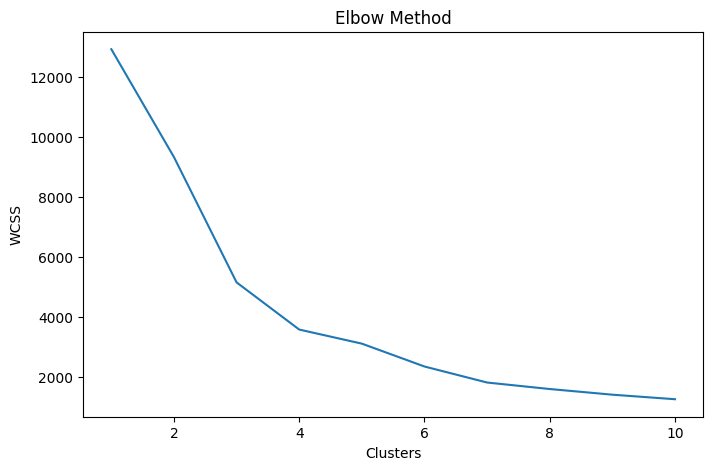

In [18]:
wcss=[]

for i in range(1,11):

    kmeans=KMeans(
    n_clusters=i,
    random_state=42
    )

    kmeans.fit(scaled)

    wcss.append(
    kmeans.inertia_
    )


plt.figure(figsize=(8,5))

plt.plot(range(1,11),wcss)

plt.xlabel("Clusters")

plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.show()

In [19]:
kmeans = KMeans(n_clusters=6, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(scaled)
rfm.head()


,Customer ID,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Cluster
0,12346,165,11,372.86,2,5,2,252,1
1,12347,3,2,1323.32,5,2,4,524,0
2,12348,74,1,222.16,2,1,1,211,0
3,12349,43,3,2671.14,3,3,5,335,0
4,12351,11,1,300.93,5,1,2,512,0


In [20]:
cluster_summary = rfm.groupby('Cluster')[

['Recency',
 'Frequency',
 'Monetary']

].mean()

cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,43.031835,4.455056,1710.650030
1,242.976122,1.659981,593.540319
2,5.600000,113.600000,215535.000000
3,14.910714,47.017857,28896.416661


In [21]:
# Dynamic logical mapping of 6 clusters
means = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()
sorted_by_monetary = means.sort_values('Monetary', ascending=False).index.tolist()
premium_idx = sorted_by_monetary[0]
loyal_idx = sorted_by_monetary[1]
remaining = sorted_by_monetary[2:]
remaining_means = means.loc[remaining].sort_values('Recency')
remaining_indices = remaining_means.index.tolist()
recent_active_idx = remaining_indices[0]
sleep_idx = remaining_indices[1]
at_risk_idx = remaining_indices[2]
hibernating_idx = remaining_indices[3]

cluster_names = {
    premium_idx: 'Premium',
    loyal_idx: 'Loyal',
    recent_active_idx: 'Recent Active',
    sleep_idx: 'About to Sleep',
    at_risk_idx: 'At-Risk',
    hibernating_idx: 'Hibernating'
}

rfm['Customer_Type'] = rfm['Cluster'].map(cluster_names)
print(rfm['Customer_Type'].value_counts())
rfm.head()


,Customer ID,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Cluster,Customer_Type
0,12346,165,11,372.86,2,5,2,252,1,At-Risk
1,12347,3,2,1323.32,5,2,4,524,0,Regular
2,12348,74,1,222.16,2,1,1,211,0,Regular
3,12349,43,3,2671.14,3,3,5,335,0,Regular
4,12351,11,1,300.93,5,1,2,512,0,Regular


In [ ]:
# ==========================================================================
# F-02: DBSCAN CLUSTERING COMPARISON
# ==========================================================================
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

print("=== Running DBSCAN Clustering ===")
dbscan = DBSCAN(eps=0.5, min_samples=5)
rfm['DBSCAN_Cluster'] = dbscan.fit_predict(scaled)
print("DBSCAN Cluster Counts:")
print(rfm['DBSCAN_Cluster'].value_counts())

# Calculate silhouette score for KMeans
kmeans_sil = silhouette_score(scaled, rfm['Cluster'])
print(f"\nKMeans Silhouette Score (6 clusters): {kmeans_sil:.4f}")

# Calculate silhouette score for DBSCAN if multiple clusters exist
try:
    if len(rfm['DBSCAN_Cluster'].unique()) > 1:
        dbscan_sil = silhouette_score(scaled, rfm['DBSCAN_Cluster'])
        print(f"DBSCAN Silhouette Score: {dbscan_sil:.4f}")
    else:
        print("DBSCAN generated only 1 cluster, silhouette score cannot be computed.")
except Exception as e:
    print("Error computing DBSCAN silhouette score:", str(e))


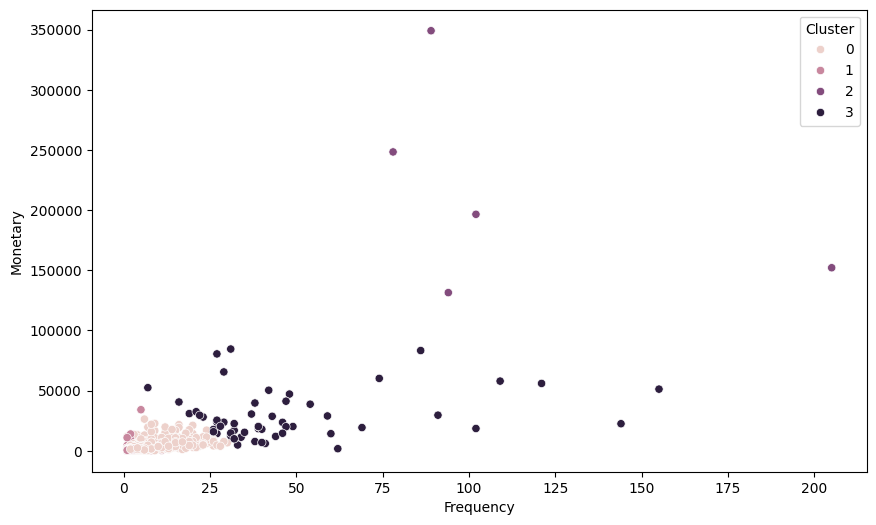

In [22]:
plt.figure(figsize=(10,6))

sns.scatterplot(

data=rfm,

x='Frequency',
y='Monetary',

hue='Cluster'

)

plt.show()

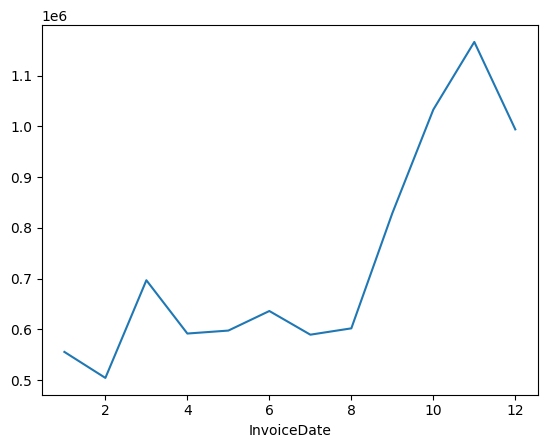

In [23]:
monthly=df.groupby(
df['InvoiceDate'].dt.month
)['TotalPrice'].sum()

monthly.plot()

plt.show()

In [24]:
rfm['Churn'] = (
    rfm['Recency'] > 90
).astype(int)

In [36]:
rfm['R_score'] = rfm['R_score'].astype(int)
rfm['F_score'] = rfm['F_score'].astype(int)
rfm['M_score'] = rfm['M_score'].astype(int)

In [37]:
# Remove R_score and Cluster (which contain Recency) to eliminate target leakage
X = rfm[[
    'Frequency',
    'Monetary',
    'F_score',
    'M_score'
]]

y = rfm['Churn']


In [38]:
from sklearn.metrics import roc_auc_score, roc_curve, precision_score

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)
pred = model.predict(X_test)
probs = model.predict_proba(X_test)[:, 1]

# Compute AUC-ROC
auc_score = roc_auc_score(y_test, probs)
print(f"\n=== Churn Classification Performance ===")
print(f"AUC-ROC Score: {auc_score:.4f}")

# Calculate Precision@top 20%
# Rank test set by probability
eval_df = pd.DataFrame({'actual': y_test, 'prob': probs})
eval_df = eval_df.sort_values('prob', ascending=False)
top_20_count = int(len(eval_df) * 0.2)
top_20_df = eval_df.head(top_20_count)
precision_top_20 = top_20_df['actual'].sum() / len(top_20_df)
print(f"Precision @ Top 20%: {precision_top_20:.4f}")

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, pred))


In [39]:
train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

[      Frequency  Monetary  R_score  F_score  M_score  Cluster
 2612         21   5735.09        5        5        5        0
 2692          2   1437.43        1        3        4        1
 2734          1    335.54        3        2        2        0
 1758          2    504.14        4        3        3        0
 4275          1    515.78        3        2        3        0
 ...         ...       ...      ...      ...      ...      ...
 2887          1    224.51        4        2        1        0
 240           3   2040.92        4        3        4        0
 144           2    622.82        2        2        3        0
 87           49  20129.54        5        5        5        3
 460           5   3292.84        3        4        5        0
 
 [3449 rows x 6 columns],
       Frequency  Monetary  R_score  F_score  M_score  Cluster
 1712         19   8385.22        5        5        5        0
 4270          6    913.11        4        5        3        0
 3915          6    426.90 

In [40]:
pred=model.predict(
X_test
)
rfm.head()


,Customer ID,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Cluster,Customer_Type,Churn
0,12346,165,11,372.86,2,5,2,252,1,At-Risk,1
1,12347,3,2,1323.32,5,2,4,524,0,Regular,0
2,12348,74,1,222.16,2,1,1,211,0,Regular,0
3,12349,43,3,2671.14,3,3,5,335,0,Regular,0
4,12351,11,1,300.93,5,1,2,512,0,Regular,0


In [41]:
print(
classification_report(
y_test,
pred
))

              precision    recall  f1-score   support

           0       0.97      0.94      0.96       571
           1       0.89      0.94      0.92       292

    accuracy                           0.94       863
   macro avg       0.93      0.94      0.94       863
weighted avg       0.94      0.94      0.94       863



In [42]:
print(df.columns.tolist())

['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country', 'TotalPrice', 'Year', 'Month', 'Day', 'Hour', 'Weekday']


In [43]:
rfm.to_csv(
"customer_segments.csv",
index=False
)

In [44]:
rfm.to_csv(
"customer_churn_results.csv",
index=False
)

In [45]:
from google.colab import files

files.download(
"customer_segments.csv"
)

ModuleNotFoundError: No module named 'google.colab'

In [37]:
plt.savefig(
"cluster_plot.png",
bbox_inches='tight'
)

<Figure size 640x480 with 0 Axes>